# Decision Tree - IT22194244

### Objective
The objective of this task is to build a Decision Tree classification model to predict whether a hotel booking will be cancelled (`is_canceled = 1`) or not cancelled (`is_canceled = 0`).

### Problem Context
Hotel cancellations directly affect occupancy planning, revenue management, staffing, and overbooking decisions. A reliable cancellation prediction model helps hotels identify high-risk bookings early and take preventive actions.

### Dataset
- File used in this project: `hotel_bookings.csv`
- Public dataset source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
- Dataset size: 119,390 records and 32 attributes
- Data includes booking details such as lead time, deposit type, market segment, customer type, previous cancellations, and room-related fields

### Why Decision Tree
Decision Tree was selected because it is:
- Easy to interpret and explain during viva and report discussion
- Suitable for tabular classification problems with mixed feature types
- Capable of capturing non-linear relationships between booking features and cancellation outcomes
- Useful for extracting feature importance to identify key drivers of cancellations

### What I Did in This Notebook
1. Loaded and explored the dataset (shape, data types, missing values, target distribution)
2. Cleaned data and handled missing values
3. Removed data leakage columns (`reservation_status` and `reservation_status_date`)
4. Split data into training and testing sets using stratified sampling
5. Built a baseline Decision Tree model with preprocessing
6. Evaluated baseline performance using accuracy, precision, recall, F1-score, and confusion matrix
7. Tuned hyperparameters using GridSearchCV
8. Compared baseline and tuned models
9. Interpreted model behavior using feature importance and added critical discussion

### Expected Outcome
This work provides an interpretable machine learning solution for cancellation prediction and highlights the most influential booking characteristics that can support better hotel decision-making.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option('display.max_columns', 100)
print('All libraries loaded successfully!')

All libraries loaded successfully!


In [27]:
# Load dataset
df = pd.read_csv('hotel_bookings.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (119390, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [28]:
# Verify dataset is loaded
print('Dataset shape:', df.shape)
print('\nFirst few rows:')
display(df.head())

Dataset shape: (119390, 32)

First few rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [29]:
# Data types and info
print('Data types and null counts:')
df.info()

Data types and null counts:
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12 

In [30]:
# Missing values analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Missing values (top 15):')
display(missing_table[missing_table['missing_count'] > 0].head(15))

Missing values (top 15):


,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


Target variable (is_canceled) distribution:


,count,percentage
is_canceled,,
0,75166,62.958372
1,44224,37.041628


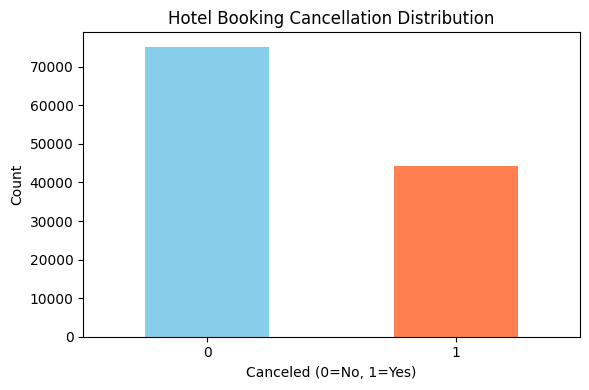


Dataset loaded and inspected


In [31]:
# Target variable distribution
print('Target variable (is_canceled) distribution:')
target_counts = df['is_canceled'].value_counts()
target_pct = df['is_canceled'].value_counts(normalize=True) * 100
target_table = pd.DataFrame({'count': target_counts, 'percentage': target_pct})
display(target_table)

plt.figure(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', color=['skyblue', 'coral'])
plt.title('Hotel Booking Cancellation Distribution')
plt.xlabel('Canceled (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\nDataset loaded and inspected')

In [32]:
# Handle missing values
df_clean = df.copy()

df_clean['children'] = df_clean['children'].fillna(df_clean['children'].median())
df_clean['country'] = df_clean['country'].fillna(df_clean['country'].mode()[0])
df_clean['agent'] = df_clean['agent'].fillna(0)
df_clean['company'] = df_clean['company'].fillna(0)

print('Remaining missing values:', df_clean.isnull().sum().sum())
print('\nMissing values handled successfully')

Remaining missing values: 0

Missing values handled successfully


In [33]:
# Remove leakage columns (known only after booking outcome)
df_clean = df_clean.drop(['reservation_status', 'reservation_status_date'], axis=1)

print('Leakage columns removed')
print('Remaining columns:', df_clean.shape[1])

Leakage columns removed
Remaining columns: 30


In [34]:
# Identify categorical and numerical columns
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = df_clean.select_dtypes(exclude=['object', 'string']).drop('is_canceled', axis=1).columns.tolist()

print('Categorical columns:', len(cat_cols))
print('Numerical columns:', len(num_cols))

print('\nPreprocessing complete. Ready for modeling.')

Categorical columns: 10
Numerical columns: 19

Preprocessing complete. Ready for modeling.


In [35]:
# Define features (X) and target (y)
X = df_clean.drop('is_canceled', axis=1)
y = df_clean['is_canceled']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nTarget distribution:')
print(y.value_counts())
print('\nTarget proportions:')
print(y.value_counts(normalize=True))

Features shape: (119390, 29)
Target shape: (119390,)

Target distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target proportions:
is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64


In [36]:
# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])
print('\nTraining set target distribution:')
print(y_train.value_counts(normalize=True))
print('\nTest set target distribution:')
print(y_test.value_counts(normalize=True))

Training set size: 95512
Test set size: 23878

Training set target distribution:
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64

Test set target distribution:
is_canceled
0    0.629575
1    0.370425
Name: proportion, dtype: float64


In [37]:
# Build preprocessing pipeline
num_cols_final = X_train.select_dtypes(exclude=['object', 'string']).columns.tolist()
cat_cols_final = X_train.select_dtypes(include=['object', 'string']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_final),
        ('num', 'passthrough', num_cols_final)
    ]
)

baseline_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

print('Baseline Decision Tree model trained successfully!')

Baseline Decision Tree model trained successfully!


In [38]:
# Baseline metrics
acc_base = accuracy_score(y_test, y_pred_base)
pre_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print('Baseline Accuracy :', round(acc_base, 4))
print('Baseline Precision:', round(pre_base, 4))
print('Baseline Recall   :', round(rec_base, 4))
print('Baseline F1-Score :', round(f1_base, 4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=['Not Cancelled', 'Cancelled']))

Baseline Accuracy : 0.8597
Baseline Precision: 0.8097
Baseline Recall   : 0.812
Baseline F1-Score : 0.8108

Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.89      0.89      0.89     15033
    Cancelled       0.81      0.81      0.81      8845

     accuracy                           0.86     23878
    macro avg       0.85      0.85      0.85     23878
 weighted avg       0.86      0.86      0.86     23878



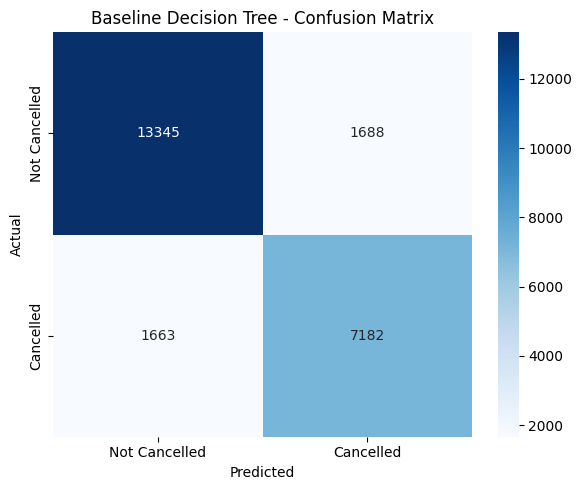

Step 5 complete: Baseline model evaluated


In [39]:
# Confusion matrix visualization
cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.title('Baseline Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Step 5 complete: Baseline model evaluated')

In [40]:
# Tune Decision Tree hyperparameters
param_grid = {
    'classifier__max_depth': [8, 12, 16, None],
    'classifier__min_samples_split': [2, 10],
    'classifier__min_samples_leaf': [1, 4],
    'classifier__criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print('Best Parameters:', grid.best_params_)
print('Best CV F1 Score:', round(grid.best_score_, 4))
print('Step 6 complete: model tuning finished')

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 16, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10}
Best CV F1 Score: 0.8058
Step 6 complete: model tuning finished


In [41]:
# Evaluate tuned model on test set
y_pred_tuned = best_model.predict(X_test)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
pre_tuned = precision_score(y_test, y_pred_tuned)
rec_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

results = pd.DataFrame([
    ['Baseline', acc_base, pre_base, rec_base, f1_base],
    ['Tuned', acc_tuned, pre_tuned, rec_tuned, f1_tuned]
], columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])

print('Baseline vs Tuned Comparison:')
display(results.round(4))

print('\nTuned Classification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=['Not Cancelled', 'Cancelled']))

Baseline vs Tuned Comparison:


,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.8597,0.8097,0.8120,0.8108
1,Tuned,0.8635,0.8406,0.7793,0.8088



Tuned Classification Report:
               precision    recall  f1-score   support

Not Cancelled       0.88      0.91      0.89     15033
    Cancelled       0.84      0.78      0.81      8845

     accuracy                           0.86     23878
    macro avg       0.86      0.85      0.85     23878
 weighted avg       0.86      0.86      0.86     23878



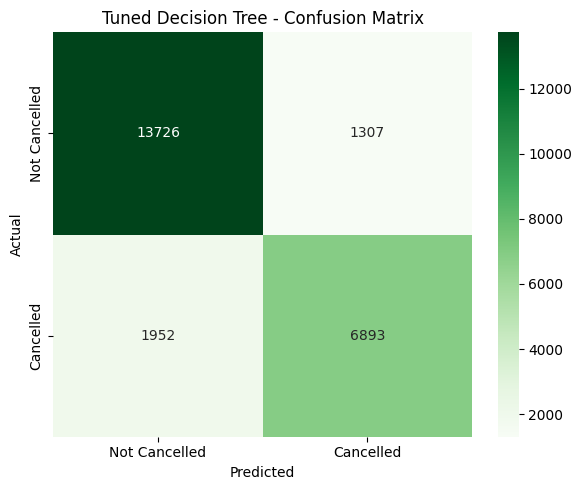

Step 7 complete: tuned model evaluated and compared


In [42]:
# Tuned confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.title('Tuned Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Step 7 complete: tuned model evaluated and compared')

Top 15 Most Important Features:


,Feature,Importance
227,cat__deposit_type_Non Refund,0.3526
197,cat__market_segment_Online TA,0.0902
233,num__lead_time,0.0818
246,num__agent,0.0790
251,num__total_of_special_requests,0.0723
149,cat__country_PRT,0.0604
250,num__required_car_parking_spaces,0.0359
234,num__arrival_date_year,0.0329
243,num__previous_cancellations,0.0308
235,num__arrival_date_week_number,0.0184


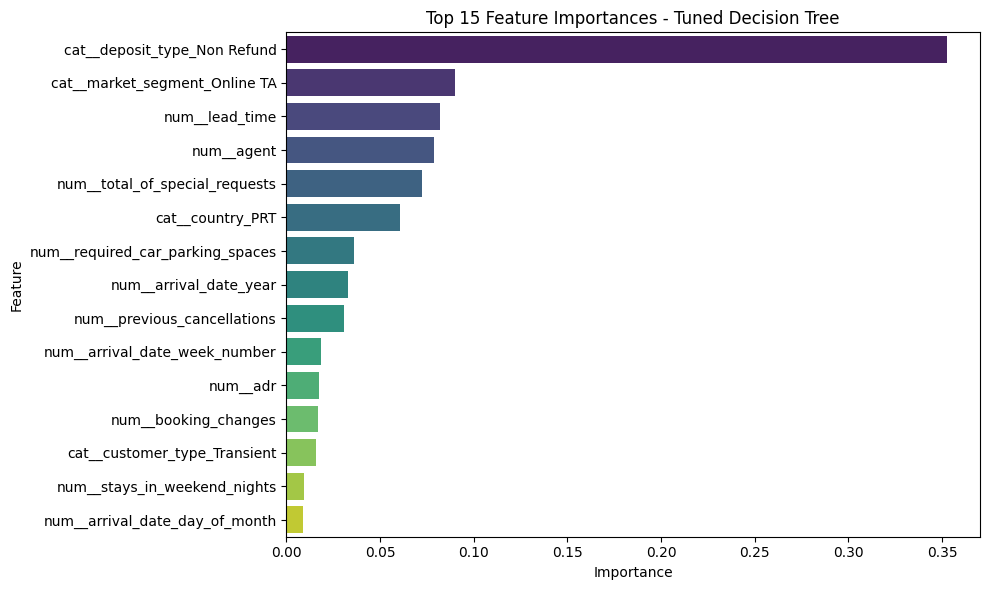

In [43]:
# Feature importance from tuned model
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
importances = best_model.named_steps['classifier'].feature_importances_

fi = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top_n = 15
print('Top 15 Most Important Features:')
display(fi.head(top_n).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi.head(top_n), x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Feature Importances - Tuned Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Final Summary
The **tuned Decision Tree** achieved higher overall accuracy and precision, while the **baseline model** retained slightly better recall/F1 balance.
For business use, choose the tuned model when minimizing false cancellation alarms is more important; choose baseline when detecting more actual cancellations is the priority.
The strongest predictor was **non-refundable deposit type**, followed by market segment and lead time, which provides actionable guidance for booking risk management.

## Critical Analysis and Discussion
1. The tuned model improved **accuracy** and **precision**, but slightly reduced **recall** and **F1** compared to baseline.
2. This indicates the tuned model is more conservative when predicting cancellations (fewer false positives, more false negatives).
3. If the business goal is to avoid false cancellation alarms, tuned model is preferred.
4. If the goal is to capture as many real cancellations as possible, baseline may be preferable due to higher recall/F1.

### Limitations
- Decision Trees can overfit if hyperparameters are not controlled.
- One-hot encoding can create many sparse features for high-cardinality categories.
- Results depend on this single train-test split and dataset quality.

### Future Work
- Compare against Random Forest and Gradient Boosting.
- Try class-weight balancing and threshold strategies to improve recall.
- Add richer time/seasonality features for better cancellation prediction.